# A small problem to demonstrate the clustering capabilities of the energiapy package.

__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2022, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"




In the following example, we use deterministic data sets with different temporal resolutions as parameters for a mixed integer linear programming formulation (MILP) for integrated network design and scheduling of an energy system.

Agglomerative hierarchial clustering is used to cluster the time series data at different resolutions (hourly, daily) separately. The optimal set of representative days are different as expected. 

Cluster 1, has hourly data such as mileage target (demand factors), intermittent renewable resource availabilty (capacity factors)

Dynamic time warping (DTW) is then used to reconcile the data and create a surrogate temporal horizon which is a combination of both optimal set of clusters. The model is then solved over the surrogate temporal horizon and results are compared to the full scale formulation. 

The entire example is implemented on the energiapy python package, which uses the resource task network (RTN)approach. The figure below describes the problem in consideration.

energiapy's capabilities, as demonstrated in this example, include:

- Component based declaration of resources, materials, processes, locations, networks, transportation modes, and scenarios with all the requisite information conviniently embedded. 
- Multiscale models can be formulated to capture dynamics at disparate temporal resolutions. 
- Tools for data analysis and collection (through NSRDB API)
- Modules to reduce the scenarios using different clustering methodologies
- Plotting of data and results
- Post analysis of results, model summaries, computational time studies
- The ability to test out a large set of scenarios seamlessly 
- Problems are formulated bespoke and can be passed on to solver of choice 
- Variety of functions for mathematical analysis. (scaling, distance calculation, matrix generation)

capabilities not demonstrated in this example include:
- piecewise linear estimation of data
- graph reformulation
- post-reformulation of problem to assuage the impact of uncertainty by accessing the integer results

modules currently in development include:
- life cycle analysis 
- resiliency analysis
- carbon accounting



![SegmentLocal](pictures\RTN.png "segment")

$\textbf{Import modules}$

In [1]:
import pandas 
from numpy import poly1d, polyfit, arange
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result 
from src.energiapy.model.formulate import formulate, Constraints, Objective
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow,\
    Clustermethod, dynamic_warping, dynamic_warping_matrix, dynamic_warping_path
from src.energiapy.utils.data_utils import load_results
import matplotlib.pyplot as plt
from matplotlib import rc
from itertools import product

**Import solar dni and wind speeds for Harris county**


We consider data for Houston for the year 2022. 
Note that the data was downloaded using the energipy.fetch_nsrdb_data() function


In [2]:
weather20_df = pandas.read_csv('data/ho_solar20.csv', index_col=0)
weather20_df.index = [i.split('+')[0] for i in weather20_df.index]
weather = weather20_df[~weather20_df.index.str.contains('02-29')] #remove leap years
weather

,wind_speed,dni
2020-01-01 00:00:00,9.5,0.0
2020-01-01 01:00:00,7.5,0.0
2020-01-01 02:00:00,6.0,0.0
2020-01-01 03:00:00,6.0,0.0
2020-01-01 04:00:00,6.0,0.0
...,...,...
2020-12-31 19:00:00,54.5,0.5
2020-12-31 20:00:00,55.5,0.0
2020-12-31 21:00:00,50.0,0.0
2020-12-31 22:00:00,46.0,181.5


**Demand data from ERCOT**

ERCOT demand data for the coastal region is used to provide a determinstic case for varying mileage demand

In [3]:
ercot20 = pandas.read_excel('data/Native_Load_2020.xlsx')
ercot = ercot20[['COAST']]
ercot['index'] = weather20_df.index
ercot = ercot.set_index('index')
ercot = ercot[~ercot.index.str.contains('02-29')]
ercot

C:\Users\cacodcar\AppData\Local\Temp\ipykernel_11996\4195252575.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ercot['index'] = weather20_df.index


,COAST
index,
2020-01-01 00:00:00,9890.091522
2020-01-01 01:00:00,9751.586415
2020-01-01 02:00:00,9603.421087
2020-01-01 03:00:00,9501.585599
2020-01-01 04:00:00,9499.426925
...,...
2020-12-31 19:00:00,12068.071946
2020-12-31 20:00:00,11818.903690
2020-12-31 21:00:00,11560.408167


**Import natural gas prices from Henry Hub Price Index**  

We use the special function energiapy.make_henry_price_df because of special requirements such as filling in empty data points (weekends, public holidays). Such function will be generalized in the next update of energipy

In [4]:
#Actual temporal scale (daily)
ng_price20 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2020, stretch=False)
ng_price_df = ng_price20
ng_price_df['index'] = [i for i in weather.index][::24]
ng_price_df = ng_price_df.drop(columns= 'scales')
ng_price = ng_price_df.set_index('index')
ng_price

,CH4
index,
2020-01-01 00:00:00,0.093304
2020-01-02 00:00:00,0.091518
2020-01-03 00:00:00,0.091964
2020-01-04 00:00:00,0.091964
2020-01-05 00:00:00,0.091964
...,...
2020-12-27 00:00:00,0.119643
2020-12-28 00:00:00,0.119643
2020-12-29 00:00:00,0.106696


<AxesSubplot:xlabel='index'>

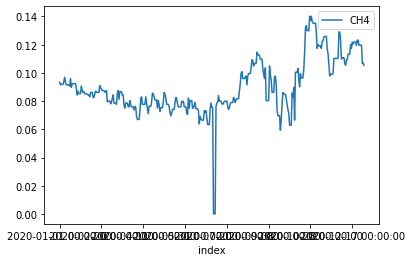

In [5]:
ng_price.plot() #data with outliers

Remove extreme outliers in the natural gas price data. (The dip in 2020 was a black swan event)

In [6]:
data = pandas.DataFrame(ng_price)
# calculate summary statistics
data_mean, data_std = data.mean(), data.std()

# identify outliers
cut_off = data_std * 3
lower, upper = data_mean - cut_off, data_mean + cut_off
# identify outliers

for i in range(len(data)):
    x = data.iloc[i].values[0]
    if x < float(lower) or x > float(upper):
        data.iloc[i] = (data.iloc[i-1] + data.iloc[i-1])/2
data
# data.set_index()


,CH4
index,
2020-01-01 00:00:00,0.093304
2020-01-02 00:00:00,0.091518
2020-01-03 00:00:00,0.091964
2020-01-04 00:00:00,0.091964
2020-01-05 00:00:00,0.091964
...,...
2020-12-27 00:00:00,0.119643
2020-12-28 00:00:00,0.119643
2020-12-29 00:00:00,0.106696


<AxesSubplot:xlabel='index'>

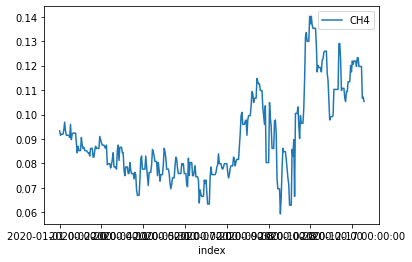

In [7]:
ng_price.plot() #data sans outliers

In [8]:
ng_price

,CH4
index,
2020-01-01 00:00:00,0.093304
2020-01-02 00:00:00,0.091518
2020-01-03 00:00:00,0.091964
2020-01-04 00:00:00,0.091964
2020-01-05 00:00:00,0.091964
...,...
2020-12-27 00:00:00,0.119643
2020-12-28 00:00:00,0.119643
2020-12-29 00:00:00,0.106696


**import cost data**


Costign data has been collected from various sources, as stated in the 'source' tab

In [9]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

$\textbf{Define temporal scale}$


The variabilities of energy systems are best captured over a discretized spatio-temporal scale. In energiapy, the first declaration is the temporal scale. 

For e.g.: Here we declare three temporal scales at different levels from right to left. The interpretation of these scales is merely symentic. Scales can be declared as the problem demands.
- 0, annual, with 1 discretization
- 1, daily with 365 discretization
- 2, hourly with 24 discretization

In essence, we are creating a temporal scale of 8760 points.

In [10]:
scales = Temporal_scale(discretization_list=[1, 365, 24], start_zero= 2020)

$\textbf{Declare constants for ease}$


In [11]:
bigM = 10**4  # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0

$\textbf{Declare resources}$

Resources can be consumed, produced, stored, discharged (or sold). 

In [12]:
Charge = Resource(name='Charge', sell=False,
                  store_max=100, basis='MW', label='Battery energy', block='energystorage')

Air_C = Resource(name='Air_C', store_max=bigM, basis='MW',
                 label='CAES energy', block='energystorage')

H2O_E = Resource(name='H2O_E', store_max=bigM, basis='MW',
                 label='PSH energy', block='energystorage')

Uranium = Resource(name='Uranium', cons_max=(1/4.17*10**(-5))*bigM,
                   price=ur_price/(250/2), basis='kg', label='Uranium', block='energyfeedstock')

Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')

Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')

H2_L = Resource(name='H2_L', store_max=10**10, revenue=2,
                mile=1/(0.1180535*1.60934), basis='kg', label='Hydrogen - Geological', block='resourcestorage')

H2_C = Resource(name='H2_C', store_max= 10**10, loss=0.025/24, revenue=2, mile=1/(0.1180535*1.60934), \
    basis='kg', label='Hydrogen - Local Cryo', block='resourcestorage')


# H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2 = Resource(name='H2', basis='kg', label='Hydrogen', block='Resource')


H2O = Resource(name='H2O', cons_max=10**10,
               price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
            
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')


CH4 = Resource(name='CH4', cons_max=100, price=0.113891, basis='kg', varying= True,\
    label='Natural gas', block='materialfeedstock')

CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')


CO2_DAC = Resource(
    name='CO2_DAC', basis='kg', label='Carbon dioxide - captured', block='carbonsequestration')

CO2_AQoff = Resource(
    name='CO2_AQoff', store_max=10**6, basis='kg', label='Carbon dioxide - sequestered', block='carbonsequestration')

CO2_EOR = Resource(
    name='CO2_EOR', store_max=10**6, basis='kg', label='Carbon dioxide - EOR', block='carbonsequestration')


CH3OH = Resource(name='CH3OH', sell=True, revenue=0.5,
                 mile=1/(0.0195508*1.60934), basis='kg', label='Methanol', block='resourcedischarge')

CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')

# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')

Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')

Mile = Resource(name = 'Mile', basis = 'miles', sell = True, demand  = True, label = 'miles driven')


$\textbf{Declare processes}$

Processes convert a resource into another through the utilization of resources. 
Essentially, the model is developed as an RTN

In [13]:
LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=100, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015')

LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=100, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015')

CAES_c = Process(name='CAES_c', conversion={Air_C: 1, Power: -1}, cost = cost_dict['HO']['moderate']['CAES_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='pilot', block='power_storage', label='Compressed air energy storage (CAES)', citation='Zakeri 2015')

CAES_d = Process(name='CAES_d', conversion={Air_C: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'},\
    intro_scale=0, prod_max=bigM, trl='discharge', block='power_storage', label='Compressed air energy storage (CAES) discharge', citation='Zakeri 2015')

PSH_c = Process(name='PSH_c', conversion={H2O_E: 1, Power: -1}, cost = cost_dict['HO']['moderate']['PSH_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='nrel', block='power_storage', label='Pumped storage hydropower (PSH)', citation='Zakeri 2015')

PSH_d = Process(name='PSH_d', conversion={H2O_E: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=bigM, trl='discharge', block='power_storage', label='Pumped storage hydropower (PSH) discharge', citation='Zakeri 2015')

WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
             prod_max=100, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
             label='Wind mill array', citation='Use windtoolkit conversion', varying= True)

PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
             prod_max=100, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                 label='Solar photovoltaics (PV) array', citation='Use pvlib conversion', varying= True)

AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
              cost=cost_dict['HO']['moderate']['AKE']['0'], prod_max=bigM, trl='utility', block='material_production',
              label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper')  # 20.833 MW required to produce 1000t/day.H2

SMRH = Process(name='SMRH', intro_scale=smrh_start, conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 1.03, CO2: 9.332},
               cost=cost_dict['HO']['moderate']['SMRH']['0'], prod_max=bigM, gwp=0, trl='enterprise', block='material_production',
               label='Steam methane reforming + CCUS', citation='Mosca 2020, 90pc capture')

SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.03, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                      block='material_production', label='Steam methane reforming', citation='Mosca 2020')

ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3364.1, Power: 1}, cost=cost_dict['HO']['moderate']['ASMR']['0'],
               intro_scale=asmr_start, gwp=9100, prod_max=bigM, land=1100/1800, trl='pilot', block='power_generation', label='Small modular reactors (SMRs)')

H2_C_c = Process(name='H2_C_c', conversion={Power: -1.10*10**(-3), H2_C: 1, H2: -1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=12000, gwp=0, trl='pilot', block='material_storage', label='Hydrogen local storage (Compressed)',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_C_d = Process(name='H2_C_d',  conversion={H2_C: -1, H2: 1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                     'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='nocost',
                 block='material_storage', label='Hydrogen local storage (Compressed) discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 0,
                                                                                                        'units': '$/kg', 'source': 'dummy'},
                 block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy')

DAC = Process(name='DAC', conversion={Power: -1.93*10**(-4), H2O: -4.048, CO2_DAC: 1}, cost=cost_dict['HO']['moderate']['DAC']['0'],
              intro_scale=4, prod_max=bigM, gwp=0, trl='pilot', block='CCUS', label='Direct air capture', citation='D. Belloti et al (2017)')

EOR = Process(name='EOR', intro_scale=0, conversion={Power: -0.00255, CO2: -1, CO2_EOR: 1, CO2_Vent: 0.67},
              cost=cost_dict['HO']['moderate']['EOR']['0'], prod_max=bigM, carbon_credit=True,
              trl='enterprise', block='CCUS', label='CO2-Enhanced oil recovery')

AQoff_SMR = Process(name='AQoff_SMR', conversion={Power: -0.00128, CO2_AQoff: 1, CO2: -1}, cost=cost_dict['HO']['moderate']['AQoff_SMR']['0'],
                    prod_max=bigM, carbon_credit=True, trl='repurposed', block='CCUS', label='Offshore aquifer CO2 sequestration (SMR)')

EV = Process(name = 'EV', conversion = {Power: -(0.2167432*10**(-3))/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'electric vehicle')


HV = Process(name = 'HV', conversion = {H2: -0.0195504/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'hydrogen vehicle')

MV = Process(name = 'HV', conversion = {CH3OH: -0.1180535/1.60934, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'methanol vehicle')

Set of processes for ease

In [14]:
process_set = {LiI_c, LiI_d, CAES_c, CAES_d, PSH_c, PSH_d, WF, PV, AKE, SMRH, SMR, ASMR, H2_C_d, H2_C_d, H2_L_c, H2_L_d, DAC, EOR, AQoff_SMR, EV, HV}

$\textbf{Declare location(s)}$


Locations have a set of available processes, the deterministic variability for the:
- price of purchase (consumption) of resource; natural gas in this case.
- demand data; mileage in this case
- capacities; here we use dni and windspeed data to capture the intermittent availability of solar and wind power

Note that there is absolutely no limitations on the number of variable resources (demand, purchase price) or processes (capacity) you can consider. 

The scale levels [0,1,2] can be used to declare the resolution at which to handle demand, capacity, and cost.

Note that not all of these are required to build a problem.

In [15]:
HO = Location(name='HO', processes= process_set, demand_factor= {Mile: ercot}, cost_factor = {CH4: ng_price}, \
        capacity_factor = {PV: pandas.DataFrame(weather['dni']), WF: pandas.DataFrame(weather['wind_speed'])},\
            scales=scales, label='Houston', demand_level=2, capacity_level= 2, cost_level= 1)

energiapy also has significant plotting capabilities. These work best for time series data which is consistent with actual temporal divisions (hours, days, years). Nevertheless, data can ofcourse be accessed directly from the location object.

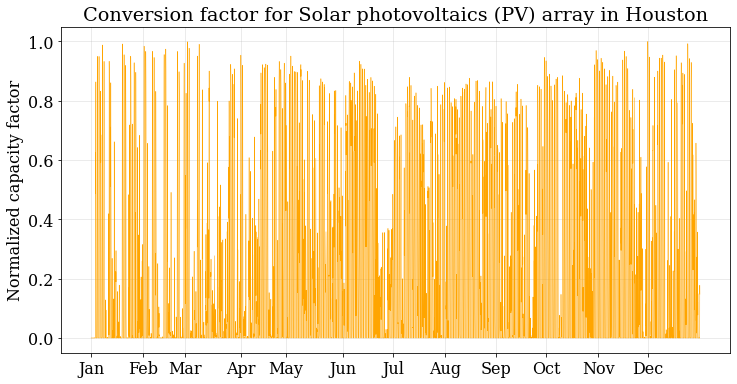

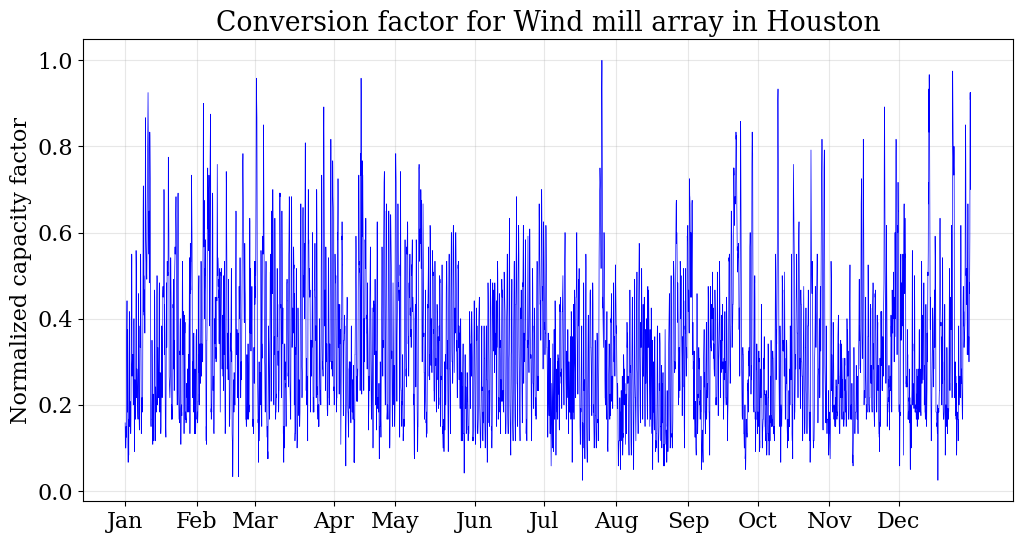

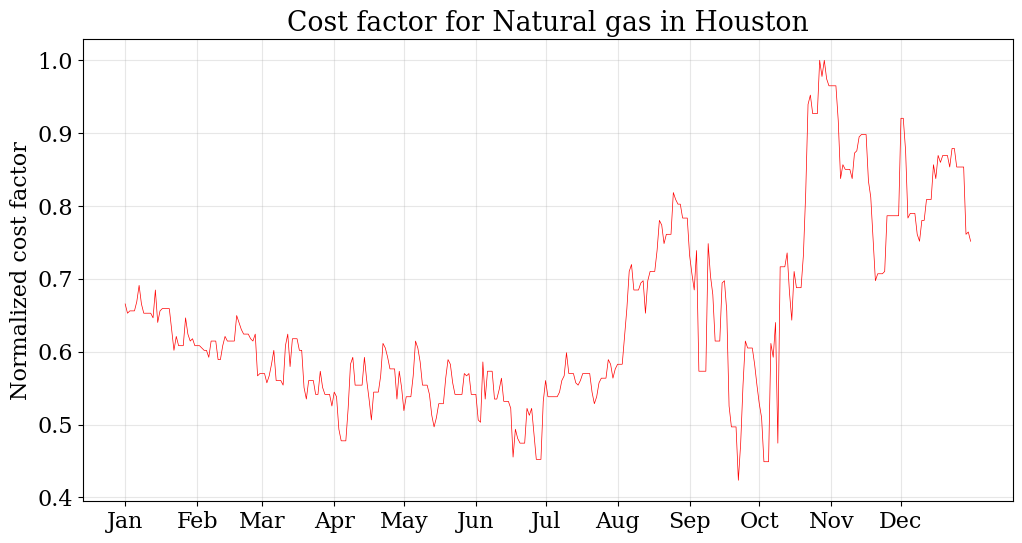

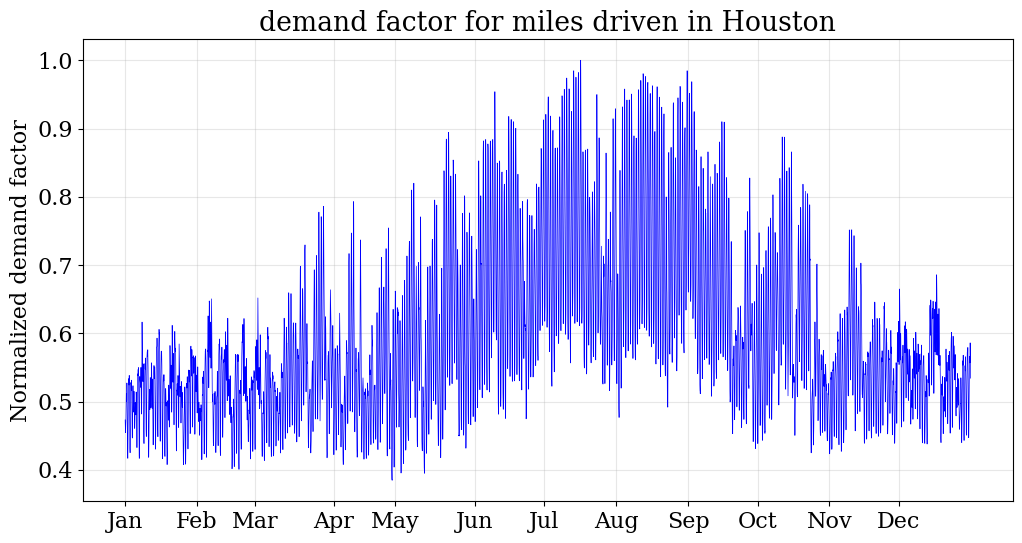

In [16]:
plot.capacity_factor(location= HO, process= PV, color= 'orange')
plot.capacity_factor(location= HO, process= WF, color= 'blue')
plot.cost_factor (location= HO, resource= CH4, color= 'red')
plot.demand_factor (location= HO, resource= Mile)

The combination of parameter data, locations, and transportation options generates a scenario. 

Scenarios are data sets that can be fed to models for analysis. 

In this case we are generating a scenario for the location houston. The scales need to be consistent.

In [17]:
scenario = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 1, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)')

**Clustering using agglomerative hierarchial clustering (AHC)**

The challenge here, lies in the different resolutions at which cost (expenditure), scheduling decisions, network decisions, and demand requirements are fulfilled.

Take the following examples:

- While natural gas prices could be accounted for at lower resolutions. The purchase decisions for natural gas are taken at a daily or weekly resolution. Hence, the scale level 1 (days).

- Scheduling (intermittent solar and wind data) and demand (seasonal and diurnal variations) however require atleast an hourly resolution to be sufficiently accounted for. These will be at the lowest scale level of 2 (hourly)

- Network decisions are typically taken in the decadal or atleast annual timeframe, hence they are determined at level 0. Note that this becomes especially important when considering dynamics such as augmentations in process efficiency and cost of technology, as also the availabilty of options.

*[Cluster 1]Clustering using demand and capacity data at scale level 1 (daily while considering the hours [365x24])*

In [18]:
reduced_scenario_hourly, rep_days_hourly,  info =  reduce_scenario(
    scenario=scenario, location=HO, periods=41, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['demand', 'capacity'])

*[Cluster 2]Clustering using cost data at scale level 1 (daily data)*

In [19]:
reduced_scenario_daily, rep_days_daily,  info =  reduce_scenario(
    scenario=scenario, location=HO, periods=41, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['cost'])

Elbow curves can be generated to determine the optimal number of clusters

c:\Users\cacodcar\OneDrive - Texas A&M University\energiapy\src\energiapy\utils\cluster_utils.py:218: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


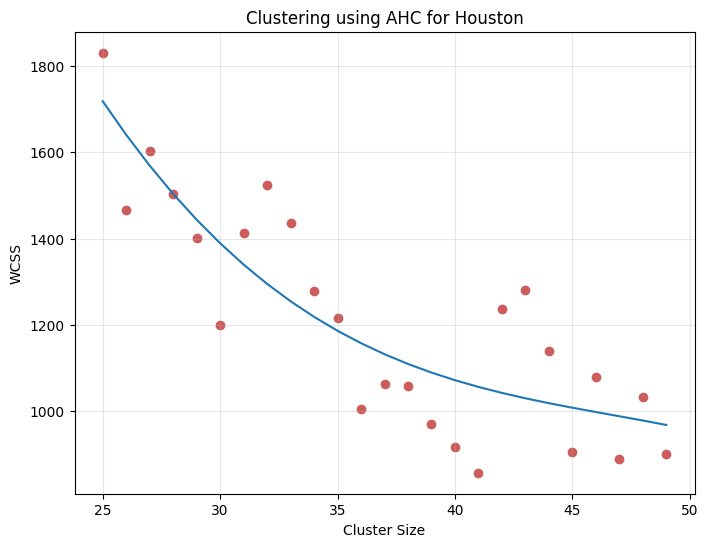

In [20]:
wcss = agg_hierarchial_elbow(scenario= scenario, location= HO, scale_level=1, include= ['demand', 'capacity'], range_list= list(range(25,50)))

**Methodology**

In Cluster 1, hourly data is clustered together using AHC
In Cluster 2, daily data is clustered using AHC

It is understood that at their originial resolutions (sans repeating daily data 24 times for uniformity). The optimal number of clusters for both can be determined individually.

Notably, this creates a mismatch. e.g. the natural gas prices for optimal representative (actual) days may co-incide with the optimal representative days for hourly data. 

The dynamic_warping option reconciles the two data clusters. The below animation is from this example:

![SegmentLocal](pictures\dtw_gif.gif "segment")

In [21]:
reduced_scenario_dtw, rep_days_dtw, info = reduce_scenario(scenario= scenario, scale_level= 2, reference_dict= rep_days_hourly,\
    include = ['cost', 'capacity', 'demand'], source_scenario = reduced_scenario_hourly, \
        target_scenario= reduced_scenario_daily, aspect= CH4, location= HO, method = Clustermethod.dynamic_warping)

$\textbf{Formulate model}$

Here we formulate a model using the constraints avalaible in energiapy. Note that the sets and variables can be intrinsically generated. The bounds for the variables are all collected from the resource, material, process, location, network, transports, and scenario objects.


In [25]:
reduced_milp_dtw = formulate(scenario= reduced_scenario_dtw, demand = 15000, \
    constraints={Constraints.cost, Constraints.inventory, Constraints.production, Constraints.land, Constraints.resource_balance}, \
        objective= Objective.cost)

In [26]:
results_reduced_dtw = solve(scenario = reduced_scenario_dtw, instance= reduced_milp_dtw, solver= 'gurobi', \
    name=f"Mobility_reduced_new", print_solversteps = True)

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 56319 rows, 40623 columns and 177071 nonzeros
Model fingerprint: 0xbacae6d9
Variable types: 40576 continuous, 47 integer (47 binary)
Coefficient statistics:
  Matrix range     [1e-06, 1e+10]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-02, 1e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 49434 rows and 24887 columns
Presolve time: 0.19s
Presolved: 6885 rows, 15736 columns, 34423 nonzeros
Variable types: 15736 continuous, 0 integer (0 binary)

Root relaxation: objective 3.650012e+09, 989 iterations, 0.24 seconds (0.70 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0   

We can now formulate a MILP using the scenario data and formulation structure

The model can then be solved to optimality

In [ ]:
results_reduced_dtw = solve(scenario = reduced_scenario_dtw, instance= reduced_milp_dtw, solver= 'gurobi', \
    name=f"Mobility_reduced_new", print_solversteps = True)

**Validation**

The results still need to validated against the full scale formulation. 


In [ ]:
milp = formulate_houston_milp(scenario= scenario, demand = 15000)

In [ ]:
results = solve(scenario = scenario, instance= milp, solver= 'gurobi', \
    name=f"Mobility_reduced_new", print_solversteps = True)

**Results and comments** 

The benefit of using dtw to reconcile the gap in sampling resource cost is not very apparent if observing the overall cost (dominated by capex). However, the performance in terms of determining the expenditure is arguably better. [Check out mickey_mouse_reduced.ipynb to compare to results based solely on AHC for clustering]

In [ ]:
results_reduced_dtw.output['B_network']


In [ ]:
plt.plot(list(results_reduced_dtw.output['C'].values()))
plt.show()
plt.plot(list(results.output['C'].values()))



In [ ]:
plt.plot(list(results_reduced_dtw.output['B'].values()))
plt.show()
plt.plot(list(results.output['B'].values()))

In [ ]:
results_reduced_dtw.output['C_location'],  results.output['C_location'] 


In [ ]:
results_reduced_dtw.output['P_location'], results.output['P_location'] 


In [ ]:
results_reduced_dtw.output['S_location'], results.output['S_location'] 


In [ ]:
results_reduced_dtw.output['Fopex_network'], results.output['Fopex_network'] 

In [ ]:
results_reduced_dtw.output['Vopex_network'],  results.output['Vopex_network'] 

In [ ]:
results_reduced_dtw.output['Capex_network'], results.output['Capex_network'] 

In [ ]:
results_reduced_dtw.output['B_network'], results.output['B_network'] 


In [ ]:
results_reduced_dtw.output['C_network'], results.output['C_network'] 


In [ ]:
results_reduced_dtw.output['Cap_P'], results.output['Cap_P'] 

In [ ]:
results_reduced_dtw.output['objective'], results.output['objective'] 


In [ ]:
results_reduced_dtw.model_summary()

In [ ]:
results.model_summary()